# WavLM Evaluation - Classification Analysis

This notebook evaluates WavLM embeddings using two primary approaches:
1. **Centroid-Based Speaker Assignment**: Assigning samples to the nearest pre-calculated group average.
2. **Embedding-Based Classification (ML Models)**: Training models (Logistic Regression, MLP, HGBT) to predict gender, age, and health status (PD vs HC).

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from IPython.display import display
from tqdm.auto import tqdm
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, HistGradientBoostingRegressor
from sklearn.model_selection import LeaveOneGroupOut, StratifiedGroupKFold
from sklearn.metrics import accuracy_score, mean_absolute_error
from sklearn.preprocessing import LabelEncoder

# Pandas display settings
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# Add root directory to sys.path
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from embeddings_eval.data_loader import load_embeddings, load_metadata
from embeddings_eval.analyzer import WavLMAnalyzer
from embeddings_eval.reporter import WavLMReporter
from embeddings_eval.constants import GROUP_DDK

In [2]:
DATA_DIR = "../datalocal/PC-GITA_v260210_24kHz/speaker_embeddings/wavLM"
META_PATH = "../datalocal/PC-GITA_v260210_24kHz/_metadata/PCGITAtoPD_mapping.csv"

print("Loading data and metadata...")
metadata = load_metadata(META_PATH)
embeddings = load_embeddings(DATA_DIR, metadata=metadata)
analyzer = WavLMAnalyzer(embeddings)
reporter = WavLMReporter(analyzer)

print(f"Loaded {len(embeddings)} samples.")

Loading data and metadata...
Loaded 2964 samples.


# I. Centroid-Based Speaker Assignment

Assigning each sample to the nearest available group centroid across all speakers.

In [3]:
class_df = reporter.generate_classification_report()
agg_df_centroid = reporter.generate_aggregated_classification_report(class_df)

Classifying samples to centroids:   0%|          | 0/2964 [00:00<?, ?it/s]

## 1.1 Aggregated Results (PD vs HC by Task Group)

In [4]:
total_all = agg_df_centroid['total samples'].sum()
correct_all = agg_df_centroid['correct samples'].sum()
accuracy_all = (correct_all / total_all) * 100

print("--- GLOBAL CENTROID SUMMARY ---")
print(f"Total samples: {total_all}")
print(f"Correctly assigned to speaker: {correct_all}")
print(f"Global Accuracy: {accuracy_all:.2f}%")
print("------------------------------")

display(agg_df_centroid)

--- GLOBAL CENTROID SUMMARY ---
Total samples: 2964
Correctly assigned to speaker: 2538
Global Accuracy: 85.63%
------------------------------


,status,group,total samples,correct samples,accuracy %
0,HC,monologue,408,362,88.725490
1,HC,readtext,280,228,81.428571
2,HC,sentence,467,431,92.291221
3,HC,words,225,201,89.333333
4,PD,ddk,300,202,67.333333
5,PD,monologue,386,342,88.601036
6,PD,readtext,270,217,80.370370
7,PD,sentence,423,372,87.943262
8,PD,words,205,183,89.268293


## 1.2 Detailed Speaker Classification (with Top 5 Intruders)

In [5]:
display(class_df)

,speaker id,group,status,total samples,correct samples,accuracy %,top 5 intruders
0,001PD,ddk,PD,6,5,83.333333,016PD_ddk (16.7%)
1,001PD,monologue,PD,8,8,100.000000,
2,001PD,readtext,PD,5,5,100.000000,
3,001PD,sentence,PD,10,10,100.000000,
4,001PD,words,PD,5,5,100.000000,
5,002PD,ddk,PD,6,5,83.333333,012PD_ddk (16.7%)
6,002PD,monologue,PD,12,8,66.666667,"005PD_readtext (16.7%), 004PD_ddk (8.3%), 055E..."
7,002PD,readtext,PD,5,5,100.000000,
8,002PD,sentence,PD,10,9,90.000000,003PD_sentence (10.0%)
9,002PD,words,PD,5,4,80.000000,048PD_ddk (20.0%)


# II. Embedding-Based Classification (Machine Learning)

Evaluation using **StratifiedGroupKFold (n=10)** by `speaker_id` to ensure equal representation of PD and HC in folds.

In [6]:
X = np.stack([e.vector.cpu().numpy() for e in embeddings])
y_sex = np.array([e.sex for e in embeddings])
y_age = np.array([e.age for e in embeddings])
y_status = np.array([e.health_status for e in embeddings])
y_hy = np.array([e.hy for e in embeddings])
groups = np.array([e.speaker_id for e in embeddings])
task_groups = np.array([e.group for e in embeddings])

cv = StratifiedGroupKFold(n_splits=10)

def run_ml_experiment(X, y, groups, model_name='lr', task='clf', label='Experiment', return_proba=False):
    if task == 'clf':
        preds = np.zeros_like(y, dtype=object)
        probas = None
        if return_proba:
            probas = np.zeros((len(y), 2))
    else:
        preds = np.zeros_like(y, dtype=float)
    
    folds = list(cv.split(X, y, groups))
    for train_idx, test_idx in tqdm(folds, desc=f"Training {label} ({model_name.upper()})"):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        if task == 'clf':
            if model_name == 'lr':
                model = LogisticRegression(max_iter=1000)
            elif model_name == 'mlp':
                model = MLPClassifier(hidden_layer_sizes=(256, 128, 64), max_iter=500)
            elif model_name == 'hgbt':
                model = HistGradientBoostingClassifier()
            
            model.fit(X_train, y_train)
            preds[test_idx] = model.predict(X_test)
            if return_proba:
                probas[test_idx] = model.predict_proba(X_test)
        else: # Regression
            if model_name == 'ridge':
                model = Ridge()
            elif model_name == 'hgbt':
                model = HistGradientBoostingRegressor()
            
            model.fit(X_train, y_train)
            preds[test_idx] = model.predict(X_test)
        
    if return_proba:
        return preds, probas, model.classes_
    return preds

## 2.1 Sex Classification (M vs F)
Comparing Logistic Regression, 3-layer MLP, and HistGradientBoosting.

In [7]:
for m in ['lr', 'mlp', 'hgbt']:
    p = run_ml_experiment(X, y_sex, groups, model_name=m, task='clf', label='Sex')
    acc = accuracy_score(y_sex, p)
    print(f"\n--- Result for SEX ({m.upper()}) ---")
    print(f"Overall Accuracy: {acc*100:.2f}%")
    
    res_tmp = pd.DataFrame({'group': task_groups, 'true': y_sex, 'pred': p})
    res_tmp['is_correct'] = res_tmp['true'] == res_tmp['pred']
    display(res_tmp.groupby('group')['is_correct'].mean() * 100)

Training Sex (LR):   0%|          | 0/10 [00:00<?, ?it/s]


--- Result for SEX (LR) ---
Overall Accuracy: 96.29%


group
ddk          90.000000
monologue    96.473552
readtext     97.454545
sentence     97.078652
words        97.209302
Name: is_correct, dtype: float64

Training Sex (MLP):   0%|          | 0/10 [00:00<?, ?it/s]


--- Result for SEX (MLP) ---
Overall Accuracy: 95.95%


group
ddk          86.666667
monologue    95.969773
readtext     96.909091
sentence     97.865169
words        97.209302
Name: is_correct, dtype: float64

Training Sex (HGBT):   0%|          | 0/10 [00:00<?, ?it/s]


--- Result for SEX (HGBT) ---
Overall Accuracy: 96.49%


group
ddk          92.333333
monologue    96.221662
readtext     97.272727
sentence     97.415730
words        96.976744
Name: is_correct, dtype: float64

## 2.2 Age Prediction (Years)
Metric: Mean Absolute Error (MAE).

Training Age (RIDGE):   0%|          | 0/10 [00:00<?, ?it/s]


--- Result for AGE (RIDGE) ---
Overall MAE: 7.24 years (Var: 32.27)


,mean,var
group,,
ddk,7.903495,42.770751
monologue,7.158526,33.622628
readtext,7.125560,29.320110
sentence,7.258974,31.085695
words,7.045963,28.683490


Training Age (HGBT):   0%|          | 0/10 [00:00<?, ?it/s]


--- Result for AGE (HGBT) ---
Overall MAE: 7.39 years (Var: 32.71)


,mean,var
group,,
ddk,7.825453,40.383205
monologue,7.559952,33.519243
readtext,7.309145,31.655227
sentence,7.321964,31.664882
words,7.022006,29.395041


Training Age Hist (HGBT):   0%|          | 0/10 [00:00<?, ?it/s]

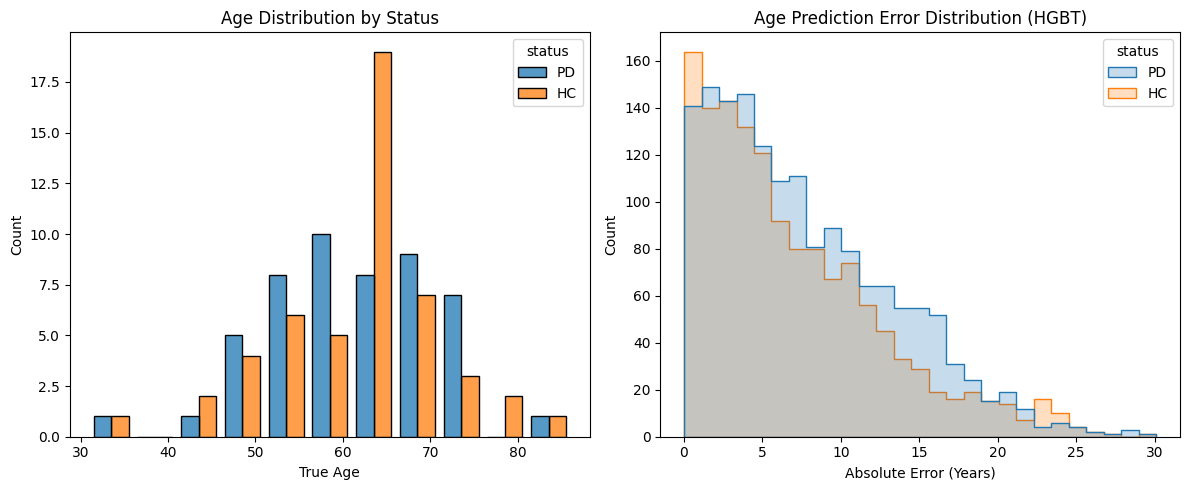

In [8]:
for m in ['ridge', 'hgbt']:
    p = run_ml_experiment(X, y_age, groups, model_name=m, task='reg', label='Age')
    err = np.abs(y_age - p)
    print(f"\n--- Result for AGE ({m.upper()}) ---")
    print(f"Overall MAE: {err.mean():.2f} years (Var: {err.var():.2f})")
    
    res_tmp = pd.DataFrame({'group': task_groups, 'abs_error': err})
    display(res_tmp.groupby('group')['abs_error'].agg(['mean', 'var']))

p_hgbt = run_ml_experiment(X, y_age, groups, model_name='hgbt', task='reg', label='Age Hist')
res_age = pd.DataFrame({'speaker_id': groups, 'status': y_status, 'true': y_age, 'pred': p_hgbt})
res_age['abs_error'] = np.abs(res_age['true'] - res_age['pred'])

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(data=res_age.drop_duplicates('speaker_id'), x='true', hue='status', multiple="dodge", shrink=.8)
plt.title("Age Distribution by Status")
plt.xlabel("True Age")
plt.subplot(1, 2, 2)
sns.histplot(data=res_age, x='abs_error', hue='status', element="step")
plt.title("Age Prediction Error Distribution (HGBT)")
plt.xlabel("Absolute Error (Years)")
plt.tight_layout()
plt.show()

## 2.3 PD vs HC Detection
**NOTE:** DDK (Diadochokinetic) task recordings are excluded from this analysis because they are only available for the Parkinson's Disease (PD) group and missing for the Healthy Control (HC) group. Including them would create a trivial classification bias.

In [9]:
# Filter out DDK data for PD/HC Detection
mask_no_ddk = (task_groups != GROUP_DDK)
X_filtered = X[mask_no_ddk]
y_status_filtered = y_status[mask_no_ddk]
y_hy_filtered = y_hy[mask_no_ddk]
groups_filtered = groups[mask_no_ddk]
task_groups_filtered = task_groups[mask_no_ddk]

print(f"PD/HC Detection: Using {len(X_filtered)} samples (excluded {len(X) - len(X_filtered)} DDK samples).")

results_status = {}
probas_status = {}
classes_status = None

for m in ['lr', 'mlp', 'hgbt']:
    p, prob, cl = run_ml_experiment(X_filtered, y_status_filtered, groups_filtered, model_name=m, task='clf', label='PD/HC', return_proba=True)
    results_status[m] = p
    probas_status[m] = prob
    classes_status = cl
    acc = accuracy_score(y_status_filtered, p)
    print(f"\n--- Result for PD/HC ({m.upper()}) ---")
    print(f"Overall Accuracy: {acc*100:.2f}%")
    
    res_tmp = pd.DataFrame({'group': task_groups_filtered, 'true': y_status_filtered, 'pred': p})
    res_tmp['is_correct'] = res_tmp['true'] == res_tmp['pred']
    display(res_tmp.groupby('group')['is_correct'].mean() * 100)

PD/HC Detection: Using 2664 samples (excluded 300 DDK samples).


Training PD/HC (LR):   0%|          | 0/10 [00:00<?, ?it/s]


--- Result for PD/HC (LR) ---
Overall Accuracy: 65.88%


group
monologue    66.750630
readtext     63.636364
sentence     66.292135
words        66.279070
Name: is_correct, dtype: float64

Training PD/HC (MLP):   0%|          | 0/10 [00:00<?, ?it/s]


--- Result for PD/HC (MLP) ---
Overall Accuracy: 62.80%


group
monologue    61.712846
readtext     60.909091
sentence     63.595506
words        65.581395
Name: is_correct, dtype: float64

Training PD/HC (HGBT):   0%|          | 0/10 [00:00<?, ?it/s]


--- Result for PD/HC (HGBT) ---
Overall Accuracy: 65.62%


group
monologue    66.246851
readtext     62.727273
sentence     65.955056
words        67.441860
Name: is_correct, dtype: float64

### 2.3.1 Aggregated PD/HC Detection (by Task Group)

We aggregate individual file predictions for each (speaker, task_group) pair using two approaches:
1. **Majority Vote**: The group is classified as the label that appears most often among its files.
2. **Average Probabilities**: We average the model's output probabilities across all files in the group and classify based on the highest average.

The **score** in parentheses represents the **Average Probability** of the predicted class (e.g., PD (0.68) means the model is on average 68% confident the samples in that group are PD).

In [10]:
def get_styled_summary(res_df, prob_matrix, classes, model_label):
    # Attach probabilities to df
    df = res_df.copy()
    for i, c_name in enumerate(classes):
        df[f'prob_{c_name}'] = prob_matrix[:, i]

    agg_results = []
    for (sid, gid, status, hy), group_data in df.groupby(['speaker_id', 'group', 'status', 'hy']):
        avg_probs = [group_data[f'prob_{c}'].mean() for c in classes]
        avg_prob_pred = classes[np.argmax(avg_probs)]
        avg_score = np.max(avg_probs)
        agg_results.append({
            'speaker_id': sid, 'group': gid, 'status': status, 'H/Y': hy,
            'avg_proba_pred': avg_prob_pred, 
            'avg_prob_val': avg_score,
            'is_correct': (avg_prob_pred == status)
        })

    agg_df = pd.DataFrame(agg_results)
    
    # Pivot groups
    speaker_pivot = agg_df.pivot(index=['speaker_id', 'status', 'H/Y'], columns='group', values='avg_proba_pred')
    
    # Overall Speaker Prediction (all files)
    overall_res = []
    for (sid, status), s_data in df.groupby(['speaker_id', 'status']):
        avg_probs = [s_data[f'prob_{c}'].mean() for c in classes]
        overall_pred = classes[np.argmax(avg_probs)]
        overall_score = np.max(avg_probs)
        overall_res.append({
            'speaker_id': sid, 'status': status,
            'Overall Classification': overall_pred, 
            'Overall Score': overall_score
        })
    
    overall_df = pd.DataFrame(overall_res).set_index(['speaker_id', 'status'])
    final_df = overall_df.join(speaker_pivot.reset_index(level='H/Y'))
    
    # Styling function - fixed to use correct indices and string comparison
    def color_rows(row):
        target = row.name[1] # status from index
        overall_pred_label = row['Overall Classification'] # Original label
        
        # Check if ALL groups match target
        group_cols = [c for c in row.index if c in ['monologue', 'readtext', 'sentence', 'words']]
        all_groups_correct = all(row[c] == target for c in group_cols if pd.notna(row[c]))
        
        styles = [''] * len(row)
        
        # Get positions in current row index
        overall_pos = row.index.get_loc('Overall Classification')
        
        # 1. Overall Incorrect -> Red text
        if overall_pred_label != target:
            styles[overall_pos] = 'color: red; font-weight: bold'
        # 2. Well Classified -> Green
        elif all_groups_correct:
            styles[overall_pos] = 'color: green; font-weight: bold'
            
        # 3. Partial group differs -> Orange background
        for c in group_cols:
            if pd.notna(row[c]) and row[c] != target:
                styles[row.index.get_loc(c)] = 'background-color: orange'
                
        return styles

    # Prepare final display with formatted strings
    display_df = final_df.copy()
    # Note: We apply styles to the version WITHOUT probabilities in the cells first,
    # or we must be careful with comparison logic.
    
    styled = display_df.style.apply(color_rows, axis=1)
    
    # Now format the 'Overall' cell for display output (after styling logic is defined)
    # We can't easily change text AFTER .style.apply if the logic depends on it,
    # so we use a formatter for the display.
    
    def format_overall(val, score):
        return f"{val} ({score:.2f})"

    # We rewrite Overall Classification to include score string but our color_rows uses the value
    # so we actually need to change how color_rows accesses the underlying data or pass original data.
    
    # Re-executing styling on a formatted DF
    display_df['Overall Classification'] = final_df.apply(lambda x: f"{x['Overall Classification']} ({x['Overall Score']:.2f})", axis=1)
    display_df = display_df.drop(columns=['Overall Score'])
    
    # Redefine logic for formatted string
    def color_rows_formatted(row):
        target = row.name[1]
        # Extract label from "PD (0.68)"
        current_overall = str(row['Overall Classification']).split(' ')[0]
        
        group_cols = [c for c in row.index if c in ['monologue', 'readtext', 'sentence', 'words']]
        all_groups_correct = all(row[c] == target for c in group_cols if pd.notna(row[c]))
        
        styles = [''] * len(row)
        overall_pos = row.index.get_loc('Overall Classification')
        
        if current_overall != target:
            styles[overall_pos] = 'color: red; font-weight: bold'
        elif all_groups_correct:
            styles[overall_pos] = 'color: green; font-weight: bold'
            
        for c in group_cols:
            if pd.notna(row[c]) and row[c] != target:
                styles[row.index.get_loc(c)] = 'background-color: orange'
        return styles

    print(f"\n--- Per-Speaker Summary ({model_label}) ---")
    display(display_df.style.apply(color_rows_formatted, axis=1))
    return agg_df

# Present results for LR and HGBT
for m in ['lr', 'hgbt']:
    res_tmp = pd.DataFrame({
        'speaker_id': groups_filtered, 'status': y_status_filtered, 'group': task_groups_filtered, 
        'true': y_status_filtered, 'pred': results_status[m], 'hy': y_hy_filtered
    })
    get_styled_summary(res_tmp, probas_status[m], classes_status, m.upper())


--- Per-Speaker Summary (LR) ---


,,Overall Classification,H/Y,monologue,readtext,sentence,words
speaker_id,status,,,,,,
001PD,PD,HC (0.77),2.0,HC,HC,HC,HC
002PD,PD,PD (0.62),1.0,PD,PD,PD,PD
003PD,PD,PD (0.69),3.0,PD,PD,PD,PD
004PD,PD,PD (0.75),2.0,PD,PD,PD,PD
005PD,PD,PD (0.57),2.0,PD,PD,nan,PD
006PD,PD,PD (0.64),2.0,PD,PD,nan,PD
007PD,PD,HC (0.60),2.0,HC,HC,HC,HC
008PD,PD,PD (0.58),3.0,PD,PD,PD,PD
009PD,PD,PD (0.59),3.0,PD,PD,PD,PD



--- Per-Speaker Summary (HGBT) ---


,,Overall Classification,H/Y,monologue,readtext,sentence,words
speaker_id,status,,,,,,
001PD,PD,HC (0.96),2.0,HC,HC,HC,HC
002PD,PD,PD (0.83),1.0,PD,PD,PD,PD
003PD,PD,PD (0.90),3.0,PD,PD,PD,PD
004PD,PD,PD (0.95),2.0,PD,PD,PD,PD
005PD,PD,PD (0.63),2.0,PD,PD,nan,HC
006PD,PD,PD (0.85),2.0,PD,PD,nan,PD
007PD,PD,HC (0.78),2.0,HC,HC,HC,HC
008PD,PD,PD (0.84),3.0,PD,PD,PD,PD
009PD,PD,HC (0.63),3.0,HC,HC,HC,PD
